# Train Risk Model - Full Google Colab Notebook

Notebook ini menjalankan training model prediksi risiko penyakit padi **sepenuhnya di cell Google Colab**.

Tidak ada pemanggilan ke `src/models/train_risk_model.py`. Semua langkah training ada di notebook ini:

1. Mount Google Drive dan set path proyek.
2. Load dataset cuaca, satelit, dan produksi padi dari file yang kamu upload sendiri.
3. Feature engineering cuaca + indeks vegetasi.
4. Membuat label risiko berbasis kondisi penyakit padi.
5. Training XGBoost.
6. Evaluasi model dengan visualisasi metrik.
7. Simpan model dan artefak ke Google Drive.

Catatan: dataset gambar penyakit padi Kaggle tidak dipakai untuk risk model tabular ini. Dataset gambar dipakai untuk model computer vision.

## 1. Mount Google Drive dan Set Project Root

In [ ]:
from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

# Ubah path ini jika folder proyek kamu berbeda.
PROJECT_ROOT = Path('/content/drive/MyDrive/Datathon/KarawangPadiGuard')

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"PROJECT_ROOT tidak ditemukan: {PROJECT_ROOT}\n"
        "Ubah PROJECT_ROOT sesuai lokasi folder proyek di Google Drive."
    )

DATA_DIR = PROJECT_ROOT / 'data'
PREPROCESS_DIR = DATA_DIR / 'preprocess'
PROCESSED_DIR = DATA_DIR / 'processed'
RAW_DIR = DATA_DIR / 'raw'
MODEL_DIR = PROJECT_ROOT / 'models'
REPORT_DIR = PROJECT_ROOT / 'reports'
LOG_DIR = PROJECT_ROOT / 'logs'

for directory in [MODEL_DIR, REPORT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR} | exists={DATA_DIR.exists()}")
print(f"PREPROCESS   : {PREPROCESS_DIR} | exists={PREPROCESS_DIR.exists()}")
print(f"PROCESSED    : {PROCESSED_DIR} | exists={PROCESSED_DIR.exists()}")
print(f"MODEL_DIR    : {MODEL_DIR}")

Mounted at /content/drive
PROJECT_ROOT : /content/drive/MyDrive/Datathon/KarawangPadiGuard
DATA_DIR     : /content/drive/MyDrive/Datathon/KarawangPadiGuard/data | exists=True
PREPROCESS   : /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess | exists=False
PROCESSED    : /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed | exists=True
MODEL_DIR    : /content/drive/MyDrive/Datathon/KarawangPadiGuard/models


## 2. Install dan Import Dependencies

In [ ]:
import sys
import subprocess

packages = [
    'numpy',
    'pandas',
    'scikit-learn',
    'xgboost',
    'joblib',
    'matplotlib',
    'seaborn',
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])

import json
import joblib
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

print('Dependencies ready.')
print(f"XGBoost version: {xgb.__version__}")

Dependencies ready.
XGBoost version: 3.2.0


## 3. Konfigurasi Training dan Dataset

Notebook mencari file tabular dari path eksplisit saja. Tidak ada pencarian rekursif Google Drive.

In [ ]:
CONFIG = {
    'model_name': 'xgboost_risk_prediction_v1',
    'risk_categories': ['Low', 'Medium', 'High'],
    'test_size': 0.2,
    'random_state': 42,
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_jobs': -1,
    'use_gpu': False,  # Set True jika runtime Colab benar-benar punya GPU yang didukung XGBoost.
}

DATASET_PATHS = {
    'weather': [
        PREPROCESS_DIR / 'weather_scraped.csv',
        PREPROCESS_DIR / 'weather_real.csv',
        PREPROCESS_DIR / 'bmkg_weather.csv',
        PREPROCESS_DIR / 'openmeteo_weather.csv',
        PREPROCESS_DIR / 'cuaca_karawang.csv',
        PROCESSED_DIR / 'weather_data.csv',
        RAW_DIR / 'weather_data.csv',
    ],
    'satellite': [
        PREPROCESS_DIR / 'sentinel2_indices.csv',
        PREPROCESS_DIR / 'sentinel_2_indices.csv',
        PREPROCESS_DIR / 'satellite_scraped.csv',
        PREPROCESS_DIR / 'satellite_real.csv',
        PREPROCESS_DIR / 'gee_satellite_indices.csv',
        PREPROCESS_DIR / 'satellite_data.csv',
        PROCESSED_DIR / 'satellite_data.csv',
        RAW_DIR / 'satellite_data.csv',
    ],
    'production': [
        PREPROCESS_DIR / 'dataset_produksi_padi_karawang_cleaned.csv',
        PREPROCESS_DIR / 'produksi_padi_karawang.csv',
        PROCESSED_DIR / 'dataset_produksi_padi_karawang_cleaned.csv',
        PROCESSED_DIR / 'produksi_padi_karawang.csv',
        RAW_DIR / 'dataset_produksi_padi_karawang_cleaned.csv',
    ],
}

DISEASE_CONDITIONS = {
    'Blast': {
        'temp_min': 25,
        'temp_max': 28,
        'humidity_min': 90,
        'name': 'Leaf Blast (Pyricularia oryzae)',
    },
    'Brown_Spot': {
        'temp_min': 28,
        'temp_max': 32,
        'humidity_min': 85,
        'name': 'Brown Spot (Cochliobolus miyabeanus)',
    },
    'Bacterial_Blight': {
        'temp_min': 25,
        'temp_max': 30,
        'humidity_min': 85,
        'name': 'Bacterial Leaf Blight (Xanthomonas oryzae)',
    },
    'Sheath_Blight': {
        'temp_min': 28,
        'temp_max': 32,
        'humidity_min': 90,
        'name': 'Sheath Blight (Rhizoctonia solani)',
    },
}

for dataset_name, paths in DATASET_PATHS.items():
    print(f"\n{dataset_name.upper()} candidates:")
    for path in paths:
        print(f"- {path} | exists={path.exists()}")


WEATHER candidates:
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/weather_scraped.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/weather_real.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/bmkg_weather.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/openmeteo_weather.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/cuaca_karawang.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed/weather_data.csv | exists=True
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/raw/weather_data.csv | exists=False

SATELLITE candidates:
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/sentinel2_indices.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/preprocess/sentinel_2_indices.csv | exists=False
- /content/drive/MyDrive/Datathon/KarawangPa

## 4. Fungsi Loader dan Standardisasi Kolom

In [ ]:
DATA_PROVENANCE = {}


def resolve_first_existing(dataset_name):
    for path in DATASET_PATHS[dataset_name]:
        if path.exists() and path.is_file():
            return path
    checked = '\n'.join(str(path) for path in DATASET_PATHS[dataset_name])
    raise FileNotFoundError(
        f"Dataset wajib '{dataset_name}' tidak ditemukan. Upload salah satu file berikut:\n{checked}"
    )


def standardize_weather_columns(df):
    rename_map = {
        'tanggal': 'date',
        'datetime': 'date',
        'time': 'date',
        'tavg': 'temperature',
        'temp': 'temperature',
        'temperature_2m': 'temperature',
        'suhu': 'temperature',
        'suhu_rata_rata': 'temperature',
        'rh': 'humidity',
        'relative_humidity_2m': 'humidity',
        'kelembapan': 'humidity',
        'kelembaban': 'humidity',
        'rr': 'rainfall',
        'precipitation': 'rainfall',
        'precipitation_sum': 'rainfall',
        'curah_hujan': 'rainfall',
        'ff_avg': 'wind_speed',
        'windspeed': 'wind_speed',
        'wind_speed_10m': 'wind_speed',
        'cloudcover': 'cloud_cover',
        'cloud_cover_mean': 'cloud_cover',
        'tekanan': 'pressure',
    }
    df = df.rename(columns={col: rename_map.get(col.lower(), col) for col in df.columns}).copy()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    for col in ['temperature', 'humidity', 'rainfall', 'wind_speed', 'cloud_cover', 'pressure', 'dew_point']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def standardize_satellite_columns(df):
    rename_map = {
        'tanggal': 'date',
        'datetime': 'date',
        'time': 'date',
        'NDVI': 'ndvi',
        'NDWI': 'ndwi',
        'EVI': 'evi',
        'SAVI': 'savi',
    }
    df = df.rename(columns={col: rename_map.get(col, rename_map.get(col.lower(), col)) for col in df.columns}).copy()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    for col in ['ndvi', 'ndwi', 'evi', 'savi', 'anomaly']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if 'month' not in df.columns and 'date' in df.columns:
        df['month'] = df['date'].dt.month
    return df


def validate_columns(df, dataset_name, required_columns):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(
            f"Dataset '{dataset_name}' belum punya kolom wajib {missing}. "
            f"Kolom tersedia: {list(df.columns)}"
        )


def load_required_dataset(dataset_name, required_columns, standardizer=None):
    path = resolve_first_existing(dataset_name)
    df = pd.read_csv(path)
    if standardizer is not None:
        df = standardizer(df)
    validate_columns(df, dataset_name, required_columns)
    DATA_PROVENANCE[dataset_name] = {
        'source_type': 'uploaded_or_project_file',
        'path': str(path),
        'rows': len(df),
        'columns': list(df.columns),
    }
    print(f"Loaded {dataset_name}: {path} | shape={df.shape}")
    return df

print('Loader ready.')

Loader ready.


## 5. Load Dataset Cuaca, Satelit, dan Produksi

In [ ]:
weather_df = load_required_dataset(
    dataset_name='weather',
    required_columns=['date', 'temperature', 'humidity', 'rainfall'],
    standardizer=standardize_weather_columns,
)
weather_df = weather_df.dropna(subset=['date']).reset_index(drop=True)

satellite_df = load_required_dataset(
    dataset_name='satellite',
    required_columns=['date'],
    standardizer=standardize_satellite_columns,
)
satellite_df = satellite_df.dropna(subset=['date']).reset_index(drop=True)

veg_cols = [col for col in ['ndvi', 'ndwi', 'evi', 'savi'] if col in satellite_df.columns]
if not {'ndvi', 'ndwi', 'evi', 'savi'}.issubset(satellite_df.columns):
    raise ValueError(
        "Dataset satellite wajib punya kolom ndvi, ndwi, evi, savi untuk training model risk saat ini. "
        f"Kolom tersedia: {list(satellite_df.columns)}"
    )

production_df = load_required_dataset(
    dataset_name='production',
    required_columns=['tahun', 'produksi_padi'],
    standardizer=None,
)
production_df.columns = [col.strip() for col in production_df.columns]
production_df['tahun'] = pd.to_numeric(production_df['tahun'], errors='coerce').astype('Int64')
production_df['produksi_padi'] = pd.to_numeric(production_df['produksi_padi'], errors='coerce')

print('\nWeather:')
print(weather_df.head())
print('\nSatellite:')
print(satellite_df.head())
print('\nProduction:')
print(production_df.head())

pd.DataFrame(DATA_PROVENANCE).T[['source_type', 'path', 'rows']]

Loaded weather: /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed/weather_data.csv | shape=(3388, 12)
Loaded satellite: /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed/satellite_data.csv | shape=(121, 7)
Loaded production: /content/drive/MyDrive/Datathon/KarawangPadiGuard/data/processed/dataset_produksi_padi_karawang_cleaned.csv | shape=(185, 8)

Weather:
        date station_id  temperature  humidity  rainfall  wind_speed  \
0 2024-01-01   Karawang         23.6      87.4       6.3         4.8   
1 2024-01-02   Karawang         27.5      85.2       3.7         1.0   
2 2024-01-03   Karawang         25.8      89.0      10.0         1.5   
3 2024-01-04   Karawang         30.2      88.3       6.9         5.4   
4 2024-01-05   Karawang         27.3      83.6       6.5         2.4   

   cloud_cover  pressure  dew_point station_name  latitude  longitude  
0         29.8    1009.3       21.1     Karawang   -6.3167   107.2867  
1         19.4    1017.9       24

,source_type,path,rows
weather,uploaded_or_project_file,/content/drive/MyDrive/Datathon/KarawangPadiGu...,3388
satellite,uploaded_or_project_file,/content/drive/MyDrive/Datathon/KarawangPadiGu...,121
production,uploaded_or_project_file,/content/drive/MyDrive/Datathon/KarawangPadiGu...,185


## 6. Integrasi Data Cuaca + Satelit

In [ ]:
# Untuk training, pertahankan granularitas data cuaca asli.
# Jika weather_df berisi beberapa stasiun per tanggal, setiap baris stasiun tetap dipakai.
# Ini menjaga hasil training konsisten dengan pipeline risk model sebelumnya.
weather_model = weather_df.copy().sort_values('date').reset_index(drop=True)

satellite_features = satellite_df.sort_values('date').reset_index(drop=True)

combined_df = pd.merge_asof(
    weather_model.sort_values('date'),
    satellite_features,
    on='date',
    direction='backward',
)

combined_df[['ndvi', 'ndwi', 'evi', 'savi']] = combined_df[['ndvi', 'ndwi', 'evi', 'savi']].bfill()
combined_df = combined_df.sort_values('date').reset_index(drop=True)

# weather_daily hanya dipakai untuk visualisasi agregat, bukan untuk training.
weather_numeric_cols = [
    col for col in ['temperature', 'humidity', 'rainfall', 'wind_speed', 'cloud_cover', 'pressure', 'dew_point']
    if col in weather_df.columns
]
weather_daily = weather_df.copy()
if 'station_name' in weather_daily.columns:
    agg_dict = {col: 'mean' for col in weather_numeric_cols if col != 'rainfall'}
    if 'rainfall' in weather_numeric_cols:
        agg_dict['rainfall'] = 'sum'
    weather_daily = weather_daily.groupby('date', as_index=False).agg(agg_dict)

print(f"Weather raw shape: {weather_df.shape}")
print(f"Weather daily aggregate shape for visualization: {weather_daily.shape}")
print(f"Satellite shape: {satellite_df.shape}")
print(f"Combined training shape: {combined_df.shape}")
print(f"Date range: {combined_df['date'].min()} to {combined_df['date'].max()}")
combined_df.head()

Weather raw shape: (3388, 12)
Weather daily aggregate shape for visualization: (847, 8)
Satellite shape: (121, 7)
Combined training shape: (3388, 18)
Date range: 2024-01-01 00:00:00 to 2026-04-26 00:00:00


,date,station_id,temperature,humidity,rainfall,wind_speed,cloud_cover,pressure,dew_point,station_name,latitude,longitude,ndvi,ndwi,evi,savi,anomaly,month
0,2024-01-01,Karawang,23.6,87.4,6.3,4.8,29.8,1009.3,21.1,Karawang,-6.3167,107.2867,0.501,0.065,0.532,0.452,NaN,NaN
1,2024-01-01,Cikampek,27.0,94.9,1.8,0.6,30.0,1009.9,25.9,Cikampek,-6.4000,107.4500,0.501,0.065,0.532,0.452,NaN,NaN
2,2024-01-01,Falkirk,29.9,86.1,8.8,4.4,64.1,1007.6,27.1,Falkirk,-6.3500,107.1500,0.501,0.065,0.532,0.452,NaN,NaN
3,2024-01-01,Pamanukan,27.2,78.9,4.8,3.9,45.1,1008.0,22.9,Pamanukan,-6.1500,107.4500,0.501,0.065,0.532,0.452,NaN,NaN
4,2024-01-02,Falkirk,25.3,81.0,5.9,3.4,38.2,1013.9,21.5,Falkirk,-6.3500,107.1500,0.501,0.065,0.532,0.452,NaN,NaN


## 7. Feature Engineering dan Label Risiko

In [ ]:
def engineer_features(df):
    df = df.copy().sort_values('date').reset_index(drop=True)

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(np.int32)
    df['season'] = df['month'].map({
        12: 'Rainy', 1: 'Rainy', 2: 'Rainy', 3: 'Rainy', 4: 'Rainy',
        5: 'Dry', 6: 'Dry', 7: 'Dry', 8: 'Dry', 9: 'Dry',
        10: 'Transitional', 11: 'Transitional',
    })

    for lag in [1, 3, 7]:
        df[f'temp_lag_{lag}'] = df['temperature'].shift(lag)
        df[f'humidity_lag_{lag}'] = df['humidity'].shift(lag)
        df[f'rainfall_lag_{lag}'] = df['rainfall'].shift(lag)

    for window in [3, 7, 14]:
        df[f'temp_rolling_{window}'] = df['temperature'].rolling(window=window).mean()
        df[f'humidity_rolling_{window}'] = df['humidity'].rolling(window=window).mean()
        df[f'rainfall_rolling_{window}'] = df['rainfall'].rolling(window=window).sum()

    df['temp_humidity_interaction'] = df['temperature'] * df['humidity']
    df['rain_intensity'] = pd.cut(
        df['rainfall'],
        bins=[-1, 0, 5, 20, float('inf')],
        labels=[0, 1, 2, 3],
    ).astype(int)

    df['blast_favorable'] = (
        (df['temperature'] >= 25) & (df['temperature'] <= 28) & (df['humidity'] >= 90)
    ).astype(int)
    df['brown_spot_favorable'] = (
        (df['temperature'] >= 28) & (df['temperature'] <= 32) & (df['humidity'] >= 85)
    ).astype(int)

    df['rainfall_7day_cum'] = df['rainfall'].rolling(7).sum()
    df['temp_trend_3d'] = df['temperature'].diff(3)
    df['humidity_trend_3d'] = df['humidity'].diff(3)

    df['extreme_heat'] = (df['temperature'] > 32).astype(int)
    df['extreme_humidity'] = (df['humidity'] > 95).astype(int)
    df['heavy_rain'] = (df['rainfall'] > 20).astype(int)

    df = df.dropna().copy()
    le = LabelEncoder()
    df['season_encoded'] = le.fit_transform(df['season'])
    return df


def calculate_risk_labels(df):
    df = df.copy()
    risk_categories = []

    for _, row in df.iterrows():
        risk_score = 0

        for disease, condition in DISEASE_CONDITIONS.items():
            if (
                condition['temp_min'] <= row['temperature'] <= condition['temp_max']
                and row['humidity'] >= condition['humidity_min']
            ):
                risk_score += 1

        if row['rainfall_7day_cum'] > 30:
            risk_score += 1
        if row['humidity_rolling_7'] > 85:
            risk_score += 1

        if risk_score >= 4:
            risk_categories.append('High')
        elif risk_score >= 2:
            risk_categories.append('Medium')
        else:
            risk_categories.append('Low')

    df['risk_category'] = risk_categories
    df['risk_score'] = [CONFIG['risk_categories'].index(category) for category in risk_categories]
    return df

model_df = engineer_features(combined_df)
model_df = calculate_risk_labels(model_df)

print(f"Model dataset shape: {model_df.shape}")
print(model_df['risk_category'].value_counts())
model_df.head()

Model dataset shape: (3364, 53)
risk_category
Low       2149
Medium     910
High       305
Name: count, dtype: int64


,date,station_id,temperature,humidity,rainfall,wind_speed,cloud_cover,pressure,dew_point,station_name,...,brown_spot_favorable,rainfall_7day_cum,temp_trend_3d,humidity_trend_3d,extreme_heat,extreme_humidity,heavy_rain,season_encoded,risk_category,risk_score
24,2024-01-07,Cikampek,26.8,87.6,7.4,2.5,41.1,1016.0,24.3,Cikampek,...,0,49.2,-1.4,9.9,0,0,0,1,Medium,1
25,2024-01-07,Falkirk,25.5,86.3,7.1,2.9,61.7,1013.2,22.8,Falkirk,...,0,49.5,2.1,4.3,0,0,0,1,Medium,1
26,2024-01-07,Pamanukan,28.6,76.9,6.9,3.0,25.2,1010.2,24.0,Pamanukan,...,0,49.9,4.1,-9.1,0,0,0,1,Low,0
27,2024-01-07,Karawang,27.6,78.0,2.3,6.9,19.5,1013.1,23.2,Karawang,...,0,43.9,0.8,-9.6,0,0,0,1,Low,0
28,2024-01-08,Karawang,23.9,88.1,5.0,3.3,27.8,1016.7,21.5,Karawang,...,0,45.7,-1.6,1.8,0,0,0,1,Low,0


## 8. Visualisasi Distribusi Risiko dan Sinyal Utama

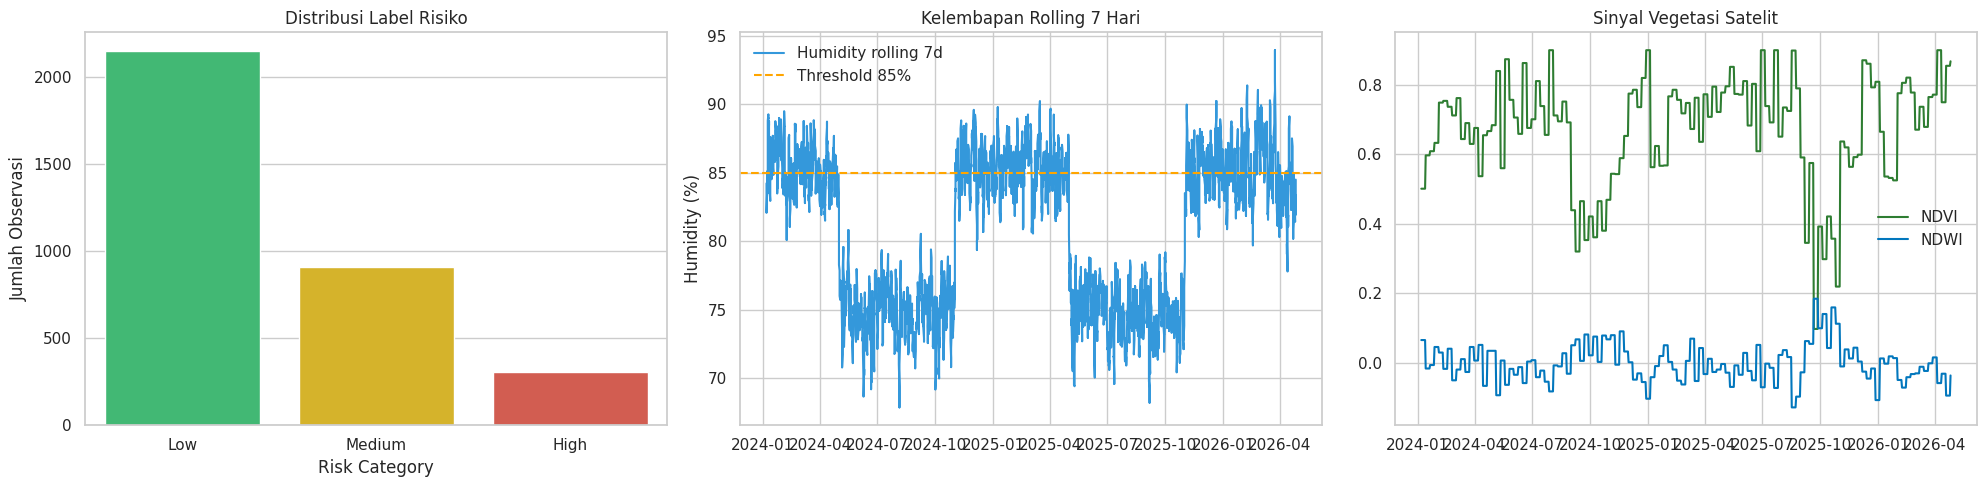

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

risk_counts = model_df['risk_category'].value_counts().reindex(CONFIG['risk_categories']).fillna(0)
sns.barplot(x=risk_counts.index, y=risk_counts.values, ax=axes[0], palette=['#2ecc71', '#f1c40f', '#e74c3c'])
axes[0].set_title('Distribusi Label Risiko')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Jumlah Observasi')

axes[1].plot(model_df['date'], model_df['humidity_rolling_7'], color='#3498db', label='Humidity rolling 7d')
axes[1].axhline(85, color='orange', linestyle='--', label='Threshold 85%')
axes[1].set_title('Kelembapan Rolling 7 Hari')
axes[1].set_ylabel('Humidity (%)')
axes[1].legend()

axes[2].plot(model_df['date'], model_df['ndvi'], color='#2e7d32', label='NDVI')
axes[2].plot(model_df['date'], model_df['ndwi'], color='#0277bd', label='NDWI')
axes[2].set_title('Sinyal Vegetasi Satelit')
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Prepare Features dan Time-Based Split

In [ ]:
FEATURE_COLS = [
    'temperature', 'humidity', 'rainfall', 'wind_speed', 'cloud_cover',
    'ndvi', 'ndwi', 'evi', 'savi',
    'month', 'day_of_year', 'week_of_year', 'season_encoded',
    'temp_lag_1', 'humidity_lag_1', 'rainfall_lag_1',
    'temp_lag_3', 'humidity_lag_3', 'rainfall_lag_3',
    'temp_lag_7', 'humidity_lag_7', 'rainfall_lag_7',
    'temp_rolling_3', 'humidity_rolling_3', 'rainfall_rolling_3',
    'temp_rolling_7', 'humidity_rolling_7', 'rainfall_rolling_7',
    'temp_rolling_14', 'humidity_rolling_14', 'rainfall_rolling_14',
    'temp_humidity_interaction', 'rain_intensity',
    'rainfall_7day_cum', 'temp_trend_3d', 'humidity_trend_3d',
    'blast_favorable', 'brown_spot_favorable',
    'extreme_heat', 'extreme_humidity', 'heavy_rain',
]

missing_features = [col for col in FEATURE_COLS if col not in model_df.columns]
if missing_features:
    raise ValueError(f"Missing features: {missing_features}")

X = model_df[FEATURE_COLS].copy()
y = model_df['risk_score'].copy()

split_idx = int(len(X) * (1 - CONFIG['test_size']))
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]
test_dates = model_df['date'].iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print(f"Feature matrix: {X.shape}")
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train date range: {model_df['date'].iloc[0]} to {model_df['date'].iloc[split_idx-1]}")
print(f"Test date range: {test_dates.iloc[0]} to {test_dates.iloc[-1]}")

Feature matrix: (3364, 41)
Train set: (2691, 41)
Test set: (673, 41)
Train date range: 2024-01-07 00:00:00 to 2025-11-09 00:00:00
Test date range: 2025-11-09 00:00:00 to 2026-04-26 00:00:00


## 10. Training XGBoost di Notebook Cell

In [ ]:
xgb_params = {
    'n_estimators': CONFIG['n_estimators'],
    'max_depth': CONFIG['max_depth'],
    'learning_rate': CONFIG['learning_rate'],
    'random_state': CONFIG['random_state'],
    'objective': 'multi:softmax',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'n_jobs': CONFIG['n_jobs'],
    'tree_method': 'hist',
}

if CONFIG['use_gpu']:
    xgb_params['device'] = 'cuda'

model = xgb.XGBClassifier(**xgb_params)

try:
    model.fit(X_train_scaled, y_train, verbose=False)
except xgb.core.XGBoostError as exc:
    if CONFIG['use_gpu']:
        print(f"GPU training gagal: {exc}")
        print('Fallback ke CPU training.')
        xgb_params.pop('device', None)
        CONFIG['use_gpu'] = False
        model = xgb.XGBClassifier(**xgb_params)
        model.fit(X_train_scaled, y_train, verbose=False)
    else:
        raise

print('Training completed.')
print(f"Training iterations: {model.n_estimators}")
print(f"Device mode: {'GPU' if CONFIG['use_gpu'] else 'CPU'}")

Training completed.
Training iterations: 200
Device mode: CPU


## 11. Evaluasi Model dan Visualisasi Metrik

Overall Metrics:
- accuracy: 0.9777
- precision_weighted: 0.9778
- recall_weighted: 0.9777
- f1_weighted: 0.9777


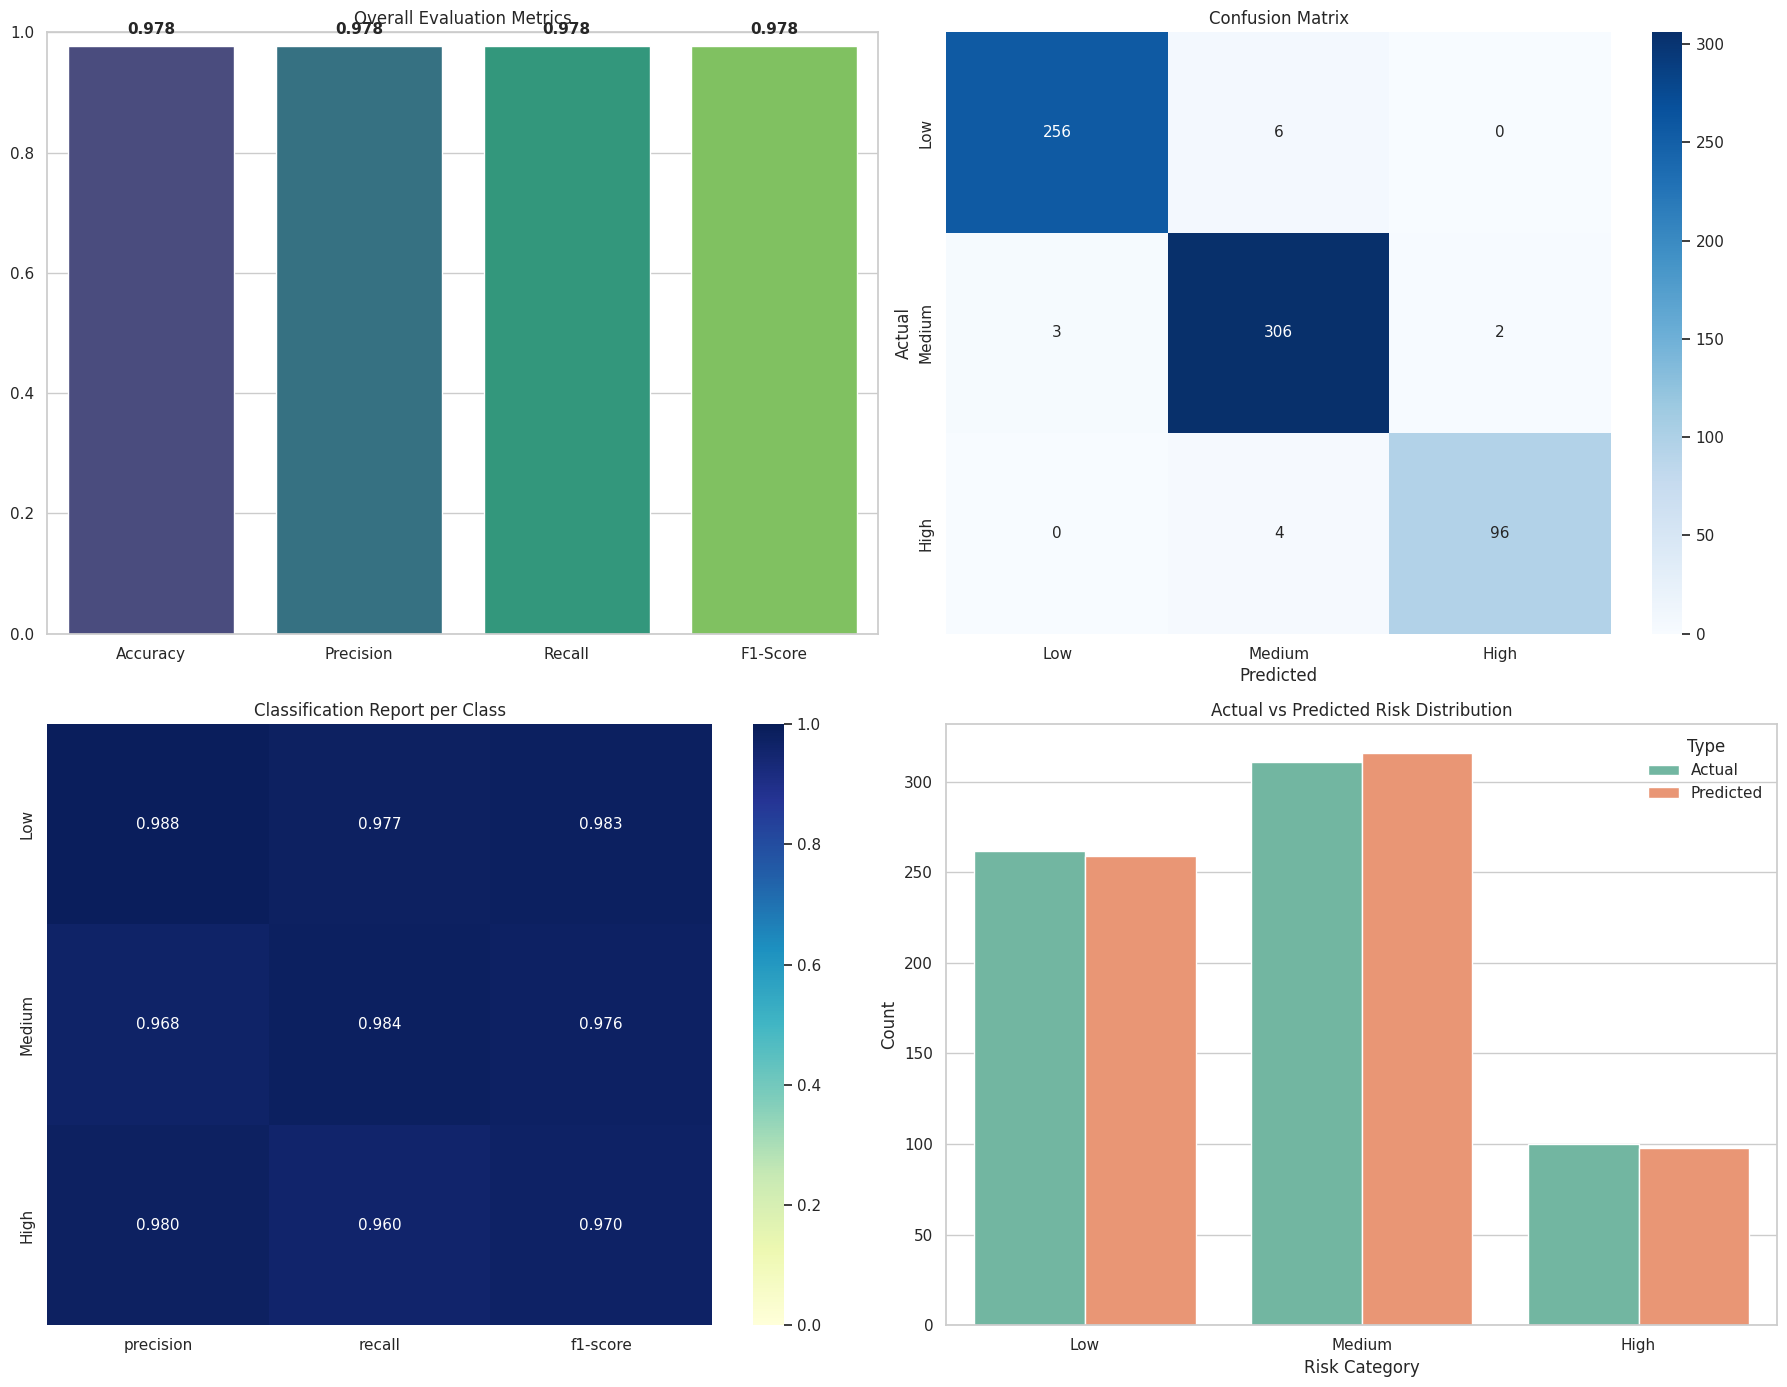

,precision,recall,f1-score,support
Low,0.988417,0.977099,0.982726,262.000000
Medium,0.968354,0.983923,0.976077,311.000000
High,0.979592,0.960000,0.969697,100.000000
accuracy,0.977712,0.977712,0.977712,0.977712
macro avg,0.978788,0.973674,0.976166,673.000000
weighted avg,0.977835,0.977712,0.977717,673.000000


In [ ]:
y_pred = model.predict(X_test_scaled)

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
}

print('Overall Metrics:')
for name, value in metrics.items():
    print(f"- {name}: {value:.4f}")

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=CONFIG['risk_categories'],
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [
    metrics['accuracy'],
    metrics['precision_weighted'],
    metrics['recall_weighted'],
    metrics['f1_weighted'],
]
sns.barplot(x=metric_names, y=metric_values, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title('Overall Evaluation Metrics')
for idx, value in enumerate(metric_values):
    axes[0, 0].text(idx, value + 0.02, f'{value:.3f}', ha='center', fontweight='bold')

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CONFIG['risk_categories'],
    yticklabels=CONFIG['risk_categories'],
    ax=axes[0, 1],
)
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

class_report_plot = report_df.loc[CONFIG['risk_categories'], ['precision', 'recall', 'f1-score']]
sns.heatmap(class_report_plot, annot=True, cmap='YlGnBu', vmin=0, vmax=1, fmt='.3f', ax=axes[1, 0])
axes[1, 0].set_title('Classification Report per Class')

pred_compare = pd.DataFrame({
    'Actual': pd.Categorical.from_codes(y_test.astype(int), CONFIG['risk_categories']),
    'Predicted': pd.Categorical.from_codes(y_pred.astype(int), CONFIG['risk_categories']),
})
pred_counts = pred_compare.melt(var_name='Type', value_name='Risk')
sns.countplot(data=pred_counts, x='Risk', hue='Type', order=CONFIG['risk_categories'], ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Actual vs Predicted Risk Distribution')
axes[1, 1].set_xlabel('Risk Category')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

report_df

## 12. Visualisasi Prediksi Sepanjang Waktu

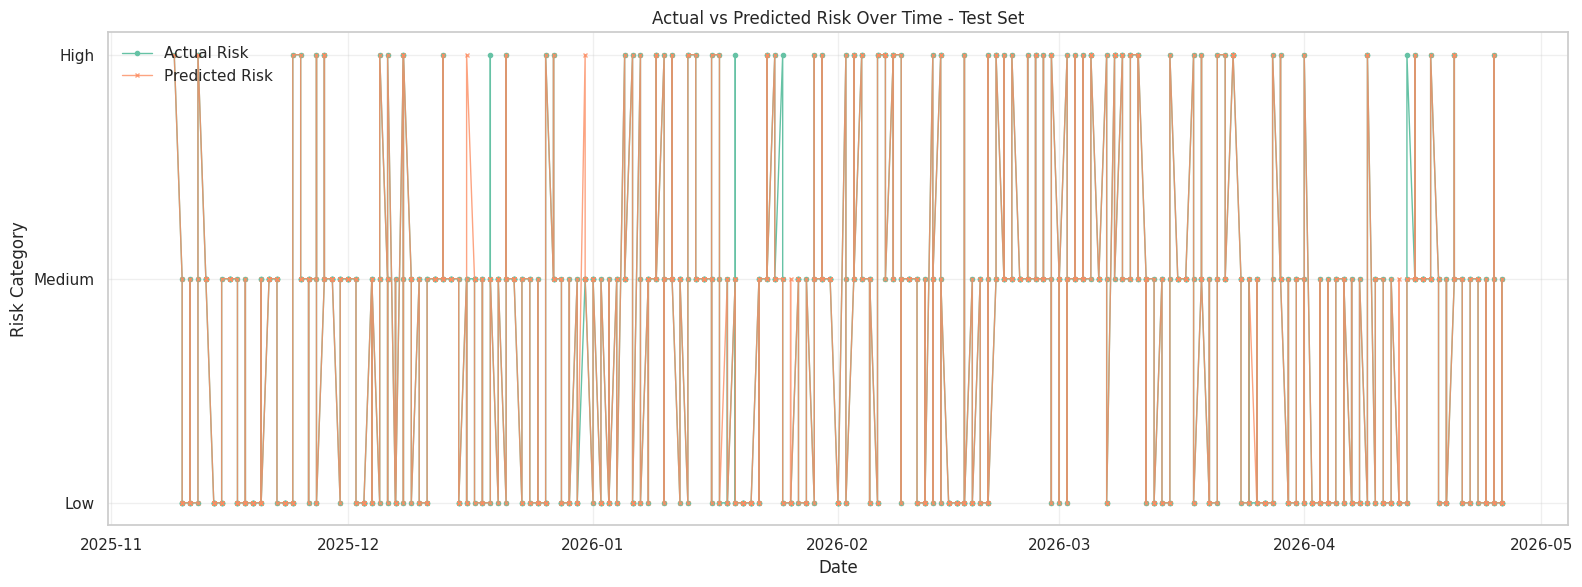

,date,actual_score,predicted_score,actual_label,predicted_label
0,2025-11-09,2,2,High,High
1,2025-11-10,1,1,Medium,Medium
2,2025-11-10,0,0,Low,Low
3,2025-11-10,0,0,Low,Low
4,2025-11-10,0,0,Low,Low
5,2025-11-11,0,0,Low,Low
6,2025-11-11,0,0,Low,Low
7,2025-11-11,1,1,Medium,Medium
8,2025-11-11,0,0,Low,Low
9,2025-11-12,0,0,Low,Low


In [ ]:
prediction_timeline = pd.DataFrame({
    'date': test_dates.reset_index(drop=True),
    'actual_score': y_test.reset_index(drop=True),
    'predicted_score': pd.Series(y_pred),
})
prediction_timeline['actual_label'] = prediction_timeline['actual_score'].map(lambda x: CONFIG['risk_categories'][int(x)])
prediction_timeline['predicted_label'] = prediction_timeline['predicted_score'].map(lambda x: CONFIG['risk_categories'][int(x)])

plt.figure(figsize=(16, 6))
plt.plot(prediction_timeline['date'], prediction_timeline['actual_score'], label='Actual Risk', marker='o', markersize=3, linewidth=1)
plt.plot(prediction_timeline['date'], prediction_timeline['predicted_score'], label='Predicted Risk', marker='x', markersize=3, linewidth=1, alpha=0.8)
plt.yticks([0, 1, 2], CONFIG['risk_categories'])
plt.title('Actual vs Predicted Risk Over Time - Test Set')
plt.xlabel('Date')
plt.ylabel('Risk Category')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

prediction_timeline.head(10)

## 13. Feature Importance

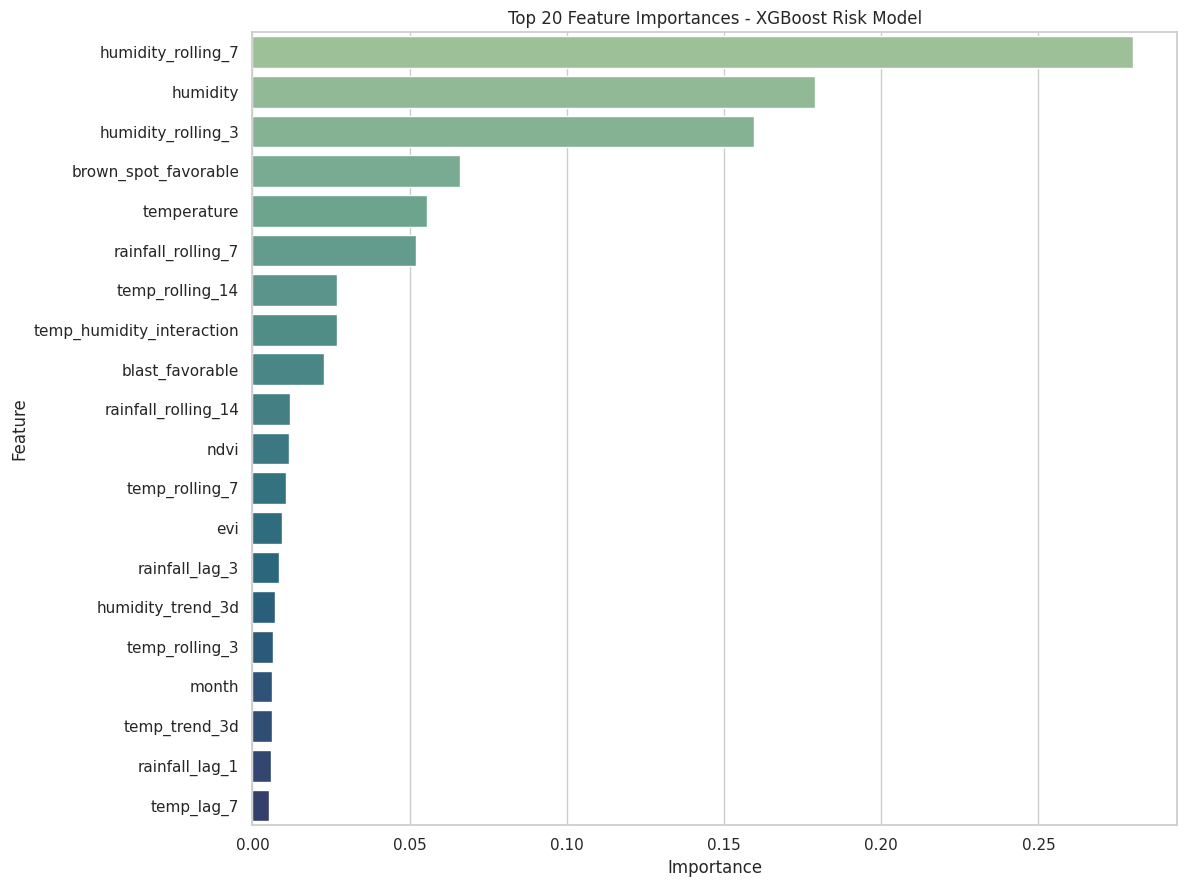

,feature,importance
26,humidity_rolling_7,0.280059
1,humidity,0.178876
23,humidity_rolling_3,0.159445
37,brown_spot_favorable,0.066153
0,temperature,0.055678
27,rainfall_rolling_7,0.051914
28,temp_rolling_14,0.027006
31,temp_humidity_interaction,0.026804
36,blast_favorable,0.022744
30,rainfall_rolling_14,0.011869


In [ ]:
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 9))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature', palette='crest')
plt.title('Top 20 Feature Importances - XGBoost Risk Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

feature_importance.head(20)

## 14. Simpan Model dan Artefak ke Google Drive

In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_name = CONFIG['model_name']

model_path = MODEL_DIR / f'{model_name}.pkl'
scaler_path = MODEL_DIR / f'{model_name}_scaler.pkl'
features_path = MODEL_DIR / f'{model_name}_features.json'
config_path = MODEL_DIR / f'{model_name}_config.json'
metrics_path = MODEL_DIR / f'{model_name}_metrics.json'
feature_importance_path = MODEL_DIR / f'{model_name}_feature_importance.csv'
confusion_matrix_path = MODEL_DIR / f'{model_name}_confusion_matrix.csv'
predictions_path = REPORT_DIR / f'{model_name}_test_predictions.csv'

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

with open(features_path, 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

config_to_save = dict(CONFIG)
config_to_save['project_root'] = str(PROJECT_ROOT)
config_to_save['data_provenance'] = DATA_PROVENANCE
with open(config_path, 'w') as f:
    json.dump(config_to_save, f, indent=2, default=str)

metrics_to_save = {
    'timestamp': datetime.now().isoformat(),
    'model_name': model_name,
    'metrics': {key: float(value) for key, value in metrics.items()},
    'classification_report': report_dict,
    'confusion_matrix': cm.tolist(),
    'feature_count': len(FEATURE_COLS),
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
}
with open(metrics_path, 'w') as f:
    json.dump(metrics_to_save, f, indent=2)

feature_importance.to_csv(feature_importance_path, index=False)
pd.DataFrame(cm, index=CONFIG['risk_categories'], columns=CONFIG['risk_categories']).to_csv(confusion_matrix_path)
prediction_timeline.to_csv(predictions_path, index=False)

print('Saved artifacts:')
for path in [
    model_path,
    scaler_path,
    features_path,
    config_path,
    metrics_path,
    feature_importance_path,
    confusion_matrix_path,
    predictions_path,
]:
    print(f"- {path} ({path.stat().st_size / 1024:.1f} KB)")

Saved artifacts:
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/models/xgboost_risk_prediction_v1.pkl (777.1 KB)
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/models/xgboost_risk_prediction_v1_scaler.pkl (2.4 KB)
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/models/xgboost_risk_prediction_v1_features.json (0.8 KB)
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/models/xgboost_risk_prediction_v1_config.json (1.5 KB)
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/models/xgboost_risk_prediction_v1_metrics.json (1.3 KB)
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/models/xgboost_risk_prediction_v1_feature_importance.csv (1.0 KB)
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/models/xgboost_risk_prediction_v1_confusion_matrix.csv (0.1 KB)
- /content/drive/MyDrive/Datathon/KarawangPadiGuard/reports/xgboost_risk_prediction_v1_test_predictions.csv (17.2 KB)


## 15. Ringkasan Hasil Training

In [ ]:
summary = {
    'accuracy': metrics['accuracy'],
    'precision_weighted': metrics['precision_weighted'],
    'recall_weighted': metrics['recall_weighted'],
    'f1_weighted': metrics['f1_weighted'],
    'top_feature': feature_importance.iloc[0]['feature'],
    'top_feature_importance': feature_importance.iloc[0]['importance'],
    'train_rows': len(X_train),
    'test_rows': len(X_test),
    'feature_count': len(FEATURE_COLS),
}

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

accuracy: 0.9777
precision_weighted: 0.9778
recall_weighted: 0.9777
f1_weighted: 0.9777
top_feature: humidity_rolling_7
top_feature_importance: 0.28005895018577576
train_rows: 2691
test_rows: 673
feature_count: 41
